# Bài Tập Về Nhà - Convolutional Neural Networks (CNN)
**Dataset:** PlantVillage

**Yêu cầu:**
- Mô hình thuần CNN, không dùng pre-train (VGG, ResNet,...).
- Chống Overfitting (sử dụng Dropout, Batch Normalization).
- Data Augmentation và chuẩn hóa đầy đủ.
- Mục tiêu: Accuracy > 90%.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os, glob, zipfile, shutil
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
# Tham so
IMG_SIZE = 128
BATCH = 32
EPOCHS = 30
DATA_DIR = './data/PlantVillage'

# --- Tu dong tai PlantVillage tu GitHub ---
if not os.path.exists(DATA_DIR) or len(os.listdir(DATA_DIR)) == 0:
    print('Dang tai dataset PlantVillage...')
    import urllib.request
    url = 'https://github.com/spMohanty/PlantVillage-Dataset/archive/refs/heads/master.zip'
    zip_path = './data/plantvillage.zip'
    os.makedirs('./data', exist_ok=True)
    urllib.request.urlretrieve(url, zip_path)
    print('Giai nen...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('./data')
    # Di chuyen thu muc color vao PlantVillage
    src = './data/PlantVillage-Dataset-master/raw/color'
    if os.path.exists(src):
        shutil.move(src, DATA_DIR)
    # Don dep
    if os.path.exists('./data/PlantVillage-Dataset-master'):
        shutil.rmtree('./data/PlantVillage-Dataset-master')
    if os.path.exists(zip_path):
        os.remove(zip_path)
    print('Tai xong!')
else:
    print('Da co dataset PlantVillage')

# Loc anh bi hong
print('Kiem tra anh bi hong...')
bad = []
for f in glob.glob(os.path.join(DATA_DIR, '**', '*.*'), recursive=True):
    try:
        img = Image.open(f)
        img.verify()
    except:
        bad.append(f)
        os.remove(f)
print(f'Da xoa {len(bad)} anh bi hong' if bad else 'Khong co anh hong')

# Augmentation cho tap train
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),       # la cay co the lat doc
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Tap test chi resize va chuan hoa
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Doc toan bo anh
full_data = torchvision.datasets.ImageFolder(DATA_DIR, transform=train_tf)
classes = full_data.classes
num_classes = len(classes)
print(f'Classes: {num_classes} lop | Tong anh: {len(full_data)}')
for i, c in enumerate(classes):
    print(f'  {i}: {c}')

# Chia 80% train, 20% test
train_size = int(0.8 * len(full_data))
test_size = len(full_data) - train_size
trainset, testset = random_split(full_data, [train_size, test_size])

# Test set khong augment
testset.dataset = torchvision.datasets.ImageFolder(DATA_DIR, transform=test_tf)

# num_workers=0 cho Windows
trainloader = DataLoader(trainset, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
testloader = DataLoader(testset, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {train_size} | Test: {test_size}')

Dang tai dataset PlantVillage...
Giai nen...
Tai xong!
Kiem tra anh bi hong...
Khong co anh hong
Classes: 38 lop | Tong anh: 54305
  0: Apple___Apple_scab
  1: Apple___Black_rot
  2: Apple___Cedar_apple_rust
  3: Apple___healthy
  4: Blueberry___healthy
  5: Cherry_(including_sour)___Powdery_mildew
  6: Cherry_(including_sour)___healthy
  7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  8: Corn_(maize)___Common_rust_
  9: Corn_(maize)___Northern_Leaf_Blight
  10: Corn_(maize)___healthy
  11: Grape___Black_rot
  12: Grape___Esca_(Black_Measles)
  13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  14: Grape___healthy
  15: Orange___Haunglongbing_(Citrus_greening)
  16: Peach___Bacterial_spot
  17: Peach___healthy
  18: Pepper,_bell___Bacterial_spot
  19: Pepper,_bell___healthy
  20: Potato___Early_blight
  21: Potato___Late_blight
  22: Potato___healthy
  23: Raspberry___healthy
  24: Soybean___healthy
  25: Squash___Powdery_mildew
  26: Strawberry___Leaf_scorch
  27: Strawberry___h

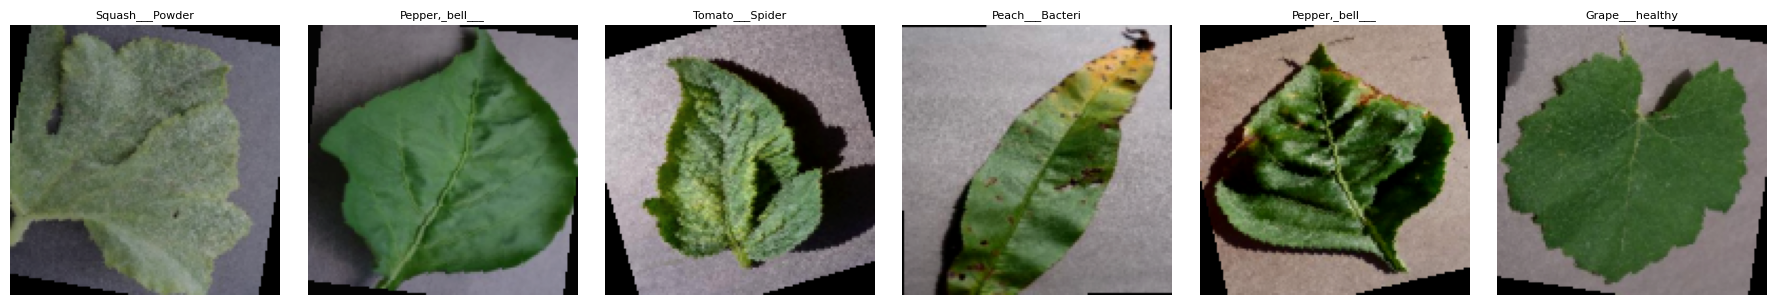

In [3]:
# Hien thi vai anh mau
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

imgs, labels = next(iter(trainloader))
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i in range(6):
    img = imgs[i].numpy().transpose(1, 2, 0) * std + mean
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(classes[labels[i]][:15], fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Mo hinh CNN cho PlantVillage (nhieu lop, anh 128x128)
class PlantCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Khoi 1: 3 -> 32 -> 64
        self.b1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2))
        # Khoi 2: 64 -> 128
        self.b2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25))
        # Khoi 3: 128 -> 256
        self.b3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.3))
        # Khoi 4: 256 -> 512
        self.b4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.4))
        # FC: 128/16=8 -> 512*8*8
        p = IMG_SIZE // 16
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * p * p, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes))

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        return self.fc(x)

model = PlantCNN(num_classes).to(device)
print(f'Tong tham so: {sum(p.numel() for p in model.parameters()):,}')
print(f'So lop phan loai: {num_classes}')

Tong tham so: 21,468,070
So lop phan loai: 38


In [5]:
criterion = nn.CrossEntropyLoss()                                       # ham mat mat
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # Adam + L2
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3) # giam LR khi acc khong tang

In [6]:
# Huan luyen
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, labels in trainloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    t_loss = loss_sum / len(trainloader)
    t_acc = 100 * correct / total

    # --- Danh gia test ---
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in testloader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss_sum += criterion(out, labels).item()
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)
    v_loss = loss_sum / len(testloader)
    v_acc = 100 * correct / total

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    tag = ''
    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), 'best_plant.pth')
        tag = ' *'

    print(f'Epoch {epoch+1:2d}/{EPOCHS} | T_Loss: {t_loss:.4f} T_Acc: {t_acc:.1f}% | V_Loss: {v_loss:.4f} V_Acc: {v_acc:.1f}%{tag}')
    scheduler.step(v_acc)

print(f'\nBest Accuracy: {best_acc:.2f}%')
model.load_state_dict(torch.load('best_plant.pth'))

Epoch  1/30 | T_Loss: 1.6752 T_Acc: 51.9% | V_Loss: 0.7219 V_Acc: 77.0% *
Epoch  2/30 | T_Loss: 0.9738 T_Acc: 69.6% | V_Loss: 0.4555 V_Acc: 85.9% *
Epoch  3/30 | T_Loss: 0.7839 T_Acc: 75.3% | V_Loss: 0.3391 V_Acc: 89.4% *
Epoch  4/30 | T_Loss: 0.6632 T_Acc: 78.8% | V_Loss: 0.2757 V_Acc: 91.3% *
Epoch  5/30 | T_Loss: 0.5876 T_Acc: 81.2% | V_Loss: 0.2273 V_Acc: 93.0% *
Epoch  6/30 | T_Loss: 0.5172 T_Acc: 83.4% | V_Loss: 0.1931 V_Acc: 93.9% *
Epoch  7/30 | T_Loss: 0.4689 T_Acc: 84.8% | V_Loss: 0.1813 V_Acc: 94.4% *
Epoch  8/30 | T_Loss: 0.4288 T_Acc: 86.1% | V_Loss: 0.1841 V_Acc: 94.0%
Epoch  9/30 | T_Loss: 0.3976 T_Acc: 87.1% | V_Loss: 0.1461 V_Acc: 95.4% *
Epoch 10/30 | T_Loss: 0.3659 T_Acc: 88.1% | V_Loss: 0.1297 V_Acc: 95.7% *
Epoch 11/30 | T_Loss: 0.3504 T_Acc: 88.8% | V_Loss: 0.1203 V_Acc: 95.9% *
Epoch 12/30 | T_Loss: 0.3319 T_Acc: 89.3% | V_Loss: 0.1089 V_Acc: 96.6% *
Epoch 13/30 | T_Loss: 0.3190 T_Acc: 89.6% | V_Loss: 0.1095 V_Acc: 96.4%
Epoch 14/30 | T_Loss: 0.3083 T_Acc: 90.0% 

<All keys matched successfully>

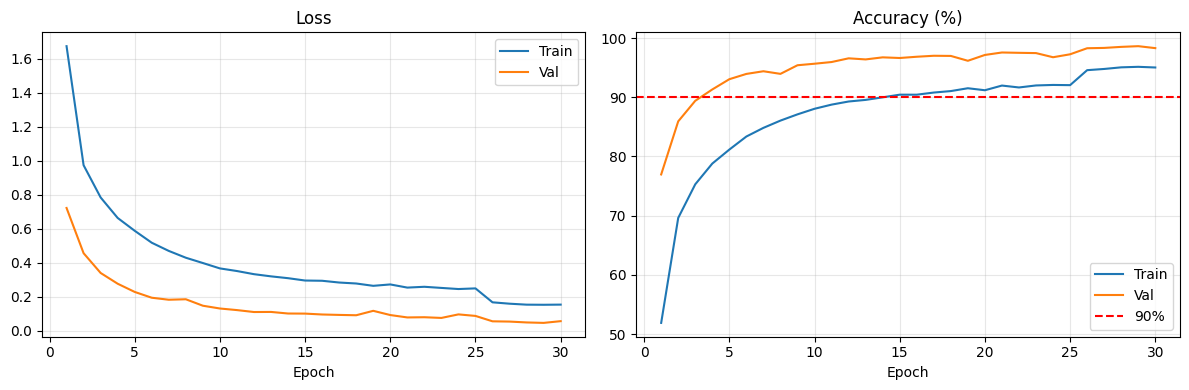

In [7]:
# Bieu do Loss va Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history['train_loss']) + 1)

ax1.plot(ep, history['train_loss'], label='Train')
ax1.plot(ep, history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, history['train_acc'], label='Train')
ax2.plot(ep, history['val_acc'], label='Val')
ax2.axhline(90, color='r', linestyle='--', label='90%')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Danh gia tung class
model.eval()
class_ok = [0] * num_classes
class_total = [0] * num_classes

with torch.no_grad():
    for imgs, labels in testloader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        
        for i in range(labels.size(0)):
            lb = labels[i].item()
            class_ok[lb] += (preds[i] == lb).item()
            class_total[lb] += 1

total_acc = 100 * sum(class_ok) / sum(class_total)
print(f'Tong Accuracy: {total_acc:.2f}%\n')
for i, name in enumerate(classes):
    acc = 100*class_ok[i]/class_total[i] if class_total[i] > 0 else 0
    print(f'  {name[:30]:30s}: {acc:.1f}% ({class_ok[i]}/{class_total[i]})')

Tong Accuracy: 98.63%

  Apple___Apple_scab            : 97.9% (142/145)
  Apple___Black_rot             : 99.0% (103/104)
  Apple___Cedar_apple_rust      : 100.0% (52/52)
  Apple___healthy               : 99.1% (324/327)
  Blueberry___healthy           : 99.7% (316/317)
  Cherry_(including_sour)___Powd: 99.6% (237/238)
  Cherry_(including_sour)___heal: 98.9% (173/175)
  Corn_(maize)___Cercospora_leaf: 96.8% (92/95)
  Corn_(maize)___Common_rust_   : 100.0% (253/253)
  Corn_(maize)___Northern_Leaf_B: 90.3% (177/196)
  Corn_(maize)___healthy        : 100.0% (231/231)
  Grape___Black_rot             : 100.0% (246/246)
  Grape___Esca_(Black_Measles)  : 99.4% (309/311)
  Grape___Leaf_blight_(Isariopsi: 99.6% (222/223)
  Grape___healthy               : 100.0% (89/89)
  Orange___Haunglongbing_(Citrus: 99.9% (1075/1076)
  Peach___Bacterial_spot        : 99.4% (467/470)
  Peach___healthy               : 100.0% (66/66)
  Pepper,_bell___Bacterial_spot : 97.2% (174/179)
  Pepper,_bell___healthy   

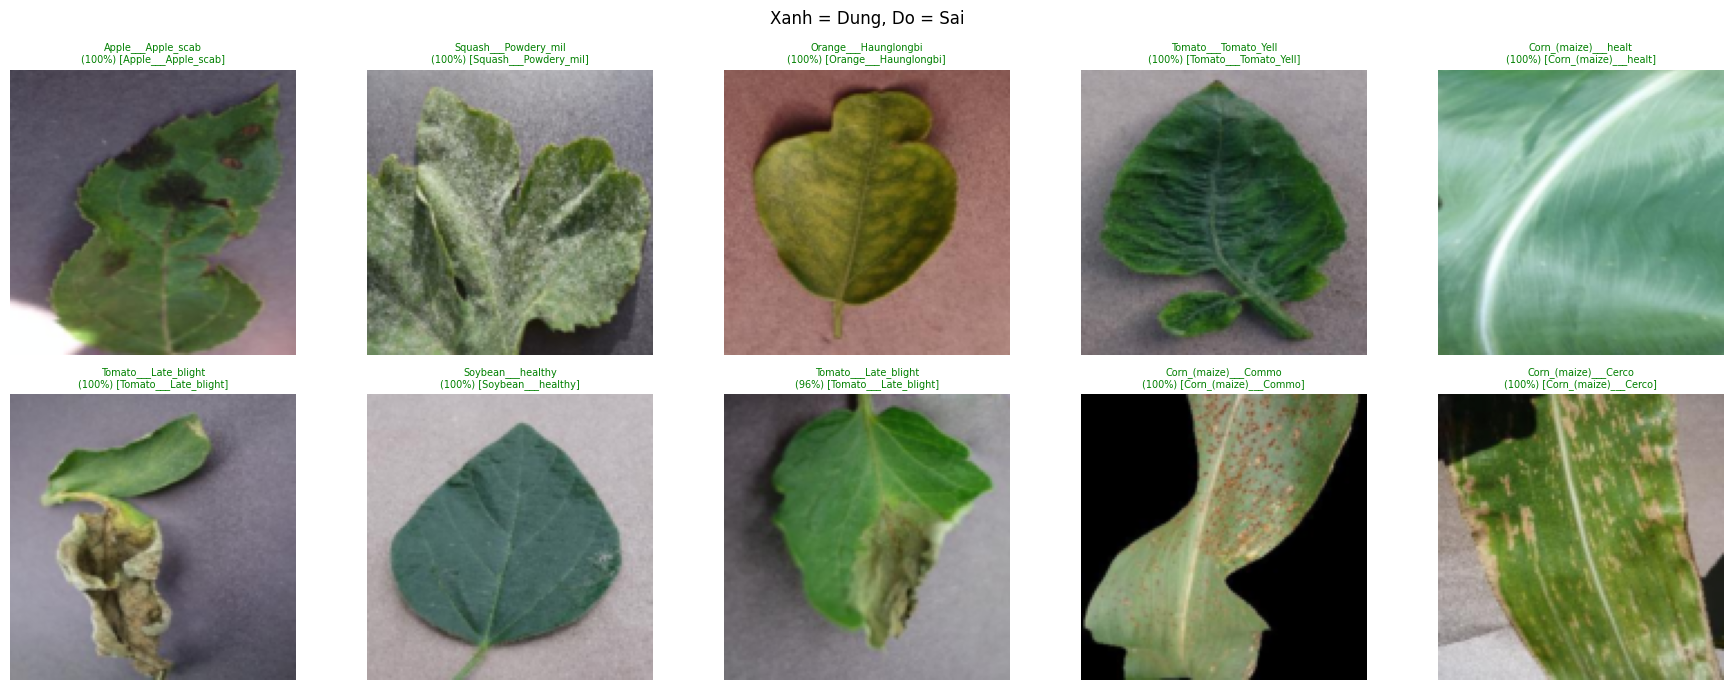

In [9]:
# Du doan thu 10 anh
model.eval()
imgs, labels = next(iter(testloader))
with torch.no_grad():
    probs = torch.softmax(model(imgs.to(device)), 1)
    preds = probs.argmax(1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, ax in enumerate(axes.flat):
    img = imgs[i].numpy().transpose(1, 2, 0) * std + mean
    ax.imshow(np.clip(img, 0, 1))
    p = classes[preds[i]][:20]
    t = classes[labels[i]][:20]
    c = probs[i][preds[i]].item() * 100
    ax.set_title(f'{p}\n({c:.0f}%) [{t}]', color='green' if preds[i]==labels[i] else 'red', fontsize=7)
    ax.axis('off')
plt.suptitle('Xanh = Dung, Do = Sai')
plt.tight_layout()
plt.show()